In [1]:
import numpy as np
import pandas as pd
# pd.set_option('display.max_columns', 30)
# pd.set_option('display.max_rows', None)
import matplotlib.pyplot as plt
import glob, json

%load_ext autoreload
%autoreload 2

from cmlreaders import get_data_index, CMLReader

In [2]:
from datetime import datetime

def ms_to_datetime(mstime):
    # Convert milliseconds to seconds and then to a datetime object
    return datetime.fromtimestamp(mstime / 1000.0)

def get_heart(subject, exp, sess, load_host_pc=False, drop_network_test=False, verbose=False):
    # Finds and reads the session log file from the task laptop
    # sess: int, original session number (used in /data10 session_*/ directory)
    log_dir = f'/data10/RAM/subjects/{subject}/behavioral/{exp}/session_{sess}'
    if load_host_pc:
        log_dir += '/elemem/*/event.log'
    else:
        if exp in ['catFR1']:
            log_dir += '/session.json'
        else:
            log_dir += '/session.jsonl'
    log_dir_list = glob.glob(log_dir)
    if verbose:
        print(log_dir_list)
    if len(log_dir_list) != 1: raise ValueError(f'Log not found: {str(log_dir_list)}')
    heart_beat = []
    # read session log to dataframe
    for log_dir in log_dir_list:
        log = []
        with open(log_dir, 'r') as fr:
            lines = fr.readlines()
            for line in lines:
                try: log.append(json.loads(line))
                except Exception as e: continue
        temp = pd.DataFrame(log)
        temp['session'] = int(sess)
        heart_beat.append(temp)
    heart_beat = pd.concat(heart_beat)
    # reads the data out of the dict format
    if load_host_pc:
        heart_beat = heart_beat[heart_beat.type.isin(['HEARTBEAT', 'HEARTBEAT_OK'])]
        heart_beat['count'] = heart_beat.data.apply(lambda x: dict.get(x, 'count'))
    else:
        heart_beat['message'] = heart_beat.data.apply(lambda x: dict.get(x, 'message'))
        heart_beat.dropna(inplace=True)
        heart_beat['type'] = heart_beat.message.apply(lambda x: dict.get(x, 'type'))
        heart_beat['data'] = heart_beat.message.apply(lambda x: dict.get(x, 'data'))
        heart_beat = heart_beat[heart_beat.type.isin(['HEARTBEAT', 'HEARTBEAT_OK'])]
        heart_beat['count'] = heart_beat.data.apply(lambda x: dict.get(x, 'count'))
        if len(heart_beat) == 0: raise ValueError('No HEARTBEAT / HEARTBEAT_OK events logged!')

    # skip heartbeats after initial heartbeat test, which is required to pass before starting a session
    if drop_network_test:
        heart_beat = heart_beat[heart_beat['count'] > 20]

    assert len(heart_beat.session.unique()) == 1, f'session numbers not unique (or not present): {heart_beat.session.unique()}'
    bpm_sent = pd.DataFrame()
    bpm_done = pd.DataFrame()
    bpm_sent = heart_beat[heart_beat.type == 'HEARTBEAT']
    bpm_done = heart_beat[heart_beat.type == 'HEARTBEAT_OK']
    bpm_done.set_index('count', inplace = True)
    bpm_sent.set_index('count', inplace = True)

    # Gets the latency between when the signal is sent and when Elemem sends the signal out
    bpm_err = bpm_done.time.astype(float) - bpm_sent.time.astype(float)
    # bpm_err = bpm_err[bpm_err.index > 20]  # not sure why Leo included this since heartbeats from network test are dropped earlier
    _max = round(bpm_err.max(), 2)
    _min = round(bpm_err.min(), 2)
    ten = round(bpm_err.quantile(.10), 2)
    ninety = round(bpm_err.quantile(.90), 2)
    out_count = bpm_err[bpm_err > 100].count()
    
    hardware_system = 'host_pc' if load_host_pc else 'task_laptop'
    if verbose:
        # print(f'{subject} {exp} session', sess)
        print('HEARTBEAT statistics for', hardware_system)
        print(f'Minimum latency: {_min} ms, Maximum latency: {_max} ms')
        print(f'Tenth percentile latency: {ten} ms. Ninetieth percentile latency: {ninety} ms')
        print(f'Latencies greater than 100 ms: {out_count / len(bpm_err) * 100:0.4}%\n')

    heart_beat = heart_beat.query('type == "HEARTBEAT"')
    if 'message' in heart_beat.columns: 
        heart_beat.drop('message', axis=1, inplace=True)
    heart_beat.set_index('count', inplace=True, drop=False)
    heart_beat.loc[:, ['latency']] = bpm_err
    heart_beat.loc[:, ['time_HEARTBEAT_OK']] = bpm_done.time
    heart_beat.loc[:, ['subject']] = subject
    heart_beat.loc[:, ['experiment']] = exp
    heart_beat.loc[:, ['session']] = sess
    heart_beat.loc[:, ['hardware_system']] = hardware_system
    heart_beat = heart_beat.reindex(columns=['subject', 'experiment', 'session', 'original_session', 'hardware_system',
                                             'count', 'time', 'time_HEARTBEAT_OK', 'latency', 'id'])

    # if verbose:
    #     heart_beat_cp = heart_beat.copy().dropna()
    #     heart_beat_cp['time'] = heart_beat_cp.time.astype(int).apply(ms_to_datetime)
    #     heart_beat_cp['time_HEARTBEAT_OK'] = heart_beat_cp.time_HEARTBEAT_OK.astype(int).apply(ms_to_datetime)
    #     display(heart_beat_cp[['latency', 'time', 'time_HEARTBEAT_OK']].head(25))

    return heart_beat


In [3]:
# check heartbeats for all behavioral tasks
exps = ['RepFR2', #'RepFR1',  # just run RepFR1 for now
        # 'EFRCourierOpenLoop', 'EFRCourierReadOnly',  # several early sessions with errors
        # 'catFR1', 'ICatFR1', 'IFR1'  # HEARTBEATs were not recorded on the task side for these experiments...
]

data = get_data_index(kind = 'r1').query('system_version == 4 and experiment in @exps')

drop_network_test = True
smokescreen = True
if smokescreen:
    # i = -2
    # data = data.query('experiment == "RepFR2"').iloc[i:i+1]
    
    # for now only load first 40 sessions since loading all somehow causes out-of-memory errors, even with 60 GB
    data = data.query('experiment == "RepFR2"').iloc[:40]
    
    # data = data.query('experiment == "catFR1"')#.iloc[i:i+1]
    # data = data.query('experiment in ["EFRCourierOpenLoop", "EFRCourierReadOnly"]')#.iloc[i:i+1]
    # data = data.query('experiment in ["catFR1", "ICatFR1", "IFR1"]')#.iloc[i:i+1]

# heartbeat errors
heartbeats = list()
for idx, row in data.iterrows():
    try:
        print('------------------------------------------------------------------------------------')
        print(f'{row.subject}, {row.experiment}, session {row.session}')
        r = CMLReader(subject=row.subject, experiment=row.experiment, session=row.session, 
                      localization=row.localization, montage=row.montage)
        evs = r.load('events')
        sess = row.original_session if not row.isna().original_session else row.session
        # load HEARTBEATs in session.jsonl (recorded by task laptop)
        tmp = get_heart(row.subject_alias, row.experiment, sess,
                        drop_network_test=drop_network_test, 
                        load_host_pc=False, verbose=True)
        tmp['original_session'] = tmp.session
        tmp.loc[:, ['session']] = row.session
        heartbeats.append(tmp)
        # load HEARTBEATs in event.log (recorded by host PC)
        tmp = get_heart(row.subject_alias, row.experiment, sess,
                        drop_network_test=drop_network_test, 
                        load_host_pc=True, verbose=True)
        tmp['original_session'] = tmp.session
        tmp.loc[:, ['session']] = row.session
        heartbeats.append(tmp)
        
    except Exception as e:
        print(f'Error on {row.subject_alias}, {row.experiment}, session {sess}:')
        print(e)
        # print()
        # raise(e)

heartbeats = pd.concat(heartbeats, ignore_index=True)
heartbeats.head(3)

------------------------------------------------------------------------------------
R1556J, RepFR2, session 0
['/data10/RAM/subjects/R1556J_1/behavioral/RepFR2/session_0/session.jsonl']
Error on R1556J_1, RepFR2, session 0:
descriptor 'get' for 'dict' objects doesn't apply to a 'str' object
------------------------------------------------------------------------------------
R1579T, RepFR2, session 0
['/data10/RAM/subjects/R1579T/behavioral/RepFR2/session_0/session.jsonl']
HEARTBEAT statistics for task_laptop
Minimum latency: 0.69 ms, Maximum latency: 230.94 ms
Tenth percentile latency: 0.97 ms. Ninetieth percentile latency: 10.03 ms
Latencies greater than 100 ms: 1.426%

['/data10/RAM/subjects/R1579T/behavioral/RepFR2/session_0/elemem/R1579T_2021-08-25_17-27-20/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.02 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------

/tmp/ipykernel_99746/3336704168.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)
/tmp/ipykernel_99746/3336704168.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


['/data10/RAM/subjects/R1587J/behavioral/RepFR2/session_0/session.jsonl']
HEARTBEAT statistics for task_laptop
Minimum latency: 0.51 ms, Maximum latency: 236.34 ms
Tenth percentile latency: 0.68 ms. Ninetieth percentile latency: 33.0 ms
Latencies greater than 100 ms: 5.893%

['/data10/RAM/subjects/R1587J/behavioral/RepFR2/session_0/elemem/R1587J_2021-10-18_12-53-28/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.0 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------------------------------------------------------------------
R1589T, RepFR2, session 0


/tmp/ipykernel_99746/3336704168.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)
/tmp/ipykernel_99746/3336704168.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


['/data10/RAM/subjects/R1589T/behavioral/RepFR2/session_0/session.jsonl']
HEARTBEAT statistics for task_laptop
Minimum latency: 0.6 ms, Maximum latency: 50.1 ms
Tenth percentile latency: 0.83 ms. Ninetieth percentile latency: 1.42 ms
Latencies greater than 100 ms: 0.0%

['/data10/RAM/subjects/R1589T/behavioral/RepFR2/session_0/elemem/R1589T_2021-10-19_15-54-32/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.02 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------------------------------------------------------------------
R1589T, RepFR2, session 1
['/data10/RAM/subjects/R1589T/behavioral/RepFR2/session_1/session.jsonl']
HEARTBEAT statistics for task_laptop
Minimum latency: 0.6 ms, Maximum latency: 42.25 ms
Tenth percentile latency: 0.82 ms. Ninetieth percentile latency: 1.43 ms
Latencies greater than 100 ms: 0.0%

['/data10/RAM/subjects/R1589T/behavioral/RepFR2/ses

...

HEARTBEAT statistics for task_laptop
Minimum latency: 0.52 ms, Maximum latency: 279.93 ms
Tenth percentile latency: 1.28 ms. Ninetieth percentile latency: 58.83 ms
Latencies greater than 100 ms: 7.187%

['/data10/RAM/subjects/R1653J_1/behavioral/RepFR2/session_2/elemem/R1653J_1_2023-11-02_10-47-00/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 30.0 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------------------------------------------------------------------
R1653J, RepFR2, session 4
['/data10/RAM/subjects/R1653J_1/behavioral/RepFR2/session_3/session.jsonl']


/tmp/ipykernel_99746/3336704168.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)
/home1/rdehaan/.conda/envs/eeg311/lib/python3.11/site-packages/cmlreaders/readers/readers.py:250: UserWarning: Changing events session field from 3 to 4 to match data index.
  warnings.warn(f'Changing events session field from {df["session"].unique()[0]} ' +


HEARTBEAT statistics for task_laptop
Minimum latency: 0.5 ms, Maximum latency: 245.83 ms
Tenth percentile latency: 1.28 ms. Ninetieth percentile latency: 53.79 ms
Latencies greater than 100 ms: 6.654%

['/data10/RAM/subjects/R1653J_1/behavioral/RepFR2/session_3/elemem/R1653J_1_2023-11-03_09-22-05/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 31.0 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%



/tmp/ipykernel_99746/3336704168.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


,subject,experiment,session,original_session,hardware_system,count,time,time_HEARTBEAT_OK,latency,id
0,R1579T,RepFR2,0,0,task_laptop,21,1.631227e+12,1.631227e+12,1.370117,91.0
1,R1579T,RepFR2,0,0,task_laptop,22,1.631227e+12,1.631227e+12,1.080078,96.0
2,R1579T,RepFR2,0,0,task_laptop,23,1.631227e+12,1.631227e+12,2.050049,99.0


In [4]:
from sklearn.linear_model import LinearRegression

def correct_event_times(events, offset, slope, time_col='mstime'):
    events = events.copy()
    events[time_col] = events[time_col] * slope + offset
    return events

def get_heartbeat_correction(df, max_latency=2, min_heartbeats=180, max_include_heartbeats=2000, 
                             max_rms_residual=2, ignore_errors=False, verbose=False, plot=False):
    # generate single-session event times corrected for heartbeat latencies
    if len(df.session.unique()) != 1: raise ValueError(f'Heartbeat dataframe contains {len(df.session.unique())} != 1 sessions!')
    
    # Filtering the individual datasets for latency < max_latency ms before merging
    task_laptop_df = df[(df['hardware_system'] == 'task_laptop') & (df['latency'] < max_latency)]
    # host PC "latencies" should be near zero since elemem just immediately sends HEARTBEAT_OK after receiving HEARTBEAT
    host_pc_df = df[(df['hardware_system'] == 'host_pc') & (df['latency'] < 1)]

    merged_df = pd.merge(task_laptop_df, host_pc_df, on='count', suffixes=('_task', '_host'))
    # drop e.g., straggling HEARTBEATs for which no HEARTBEAT_OK was sent back at the end of the task
    merged_df.dropna(subset=['latency_host', 'latency_task'], inplace=True)
    
    n_heartbeats = len(merged_df)
    if n_heartbeats < min_heartbeats:
        raise ValueError(f'Available HEARTBEATs ({len(merged_df)}) < min_heartbeats ({min_heartbeats})')
    elif n_heartbeats > max_include_heartbeats:
        # pick HEARTBEATs at extremes of range
        merged_df = pd.concat([merged_df.iloc[:max_include_heartbeats // 2],
                               merged_df.iloc[-max_include_heartbeats // 2:]])

    # adjust task times to host PC times
    lr = LinearRegression()
    lr.fit(merged_df[['time_task']], merged_df['time_host'])
    slope = lr.coef_[0]
    offset = lr.intercept_
    
    r2 = lr.score(merged_df[['time_task']], merged_df['time_host'])
    residuals = merged_df['time_host'] - lr.predict(merged_df[['time_task']])
    rms_residual = np.sqrt(((residuals)**2).mean())
    
    # adjust offset for network delay (half of the average roundtrip latency)
    average_latency = merged_df['latency_task'].mean()
    latency_correction = average_latency / 2
    adjusted_offset = offset - latency_correction

    if verbose:
        print('Number of low-latency heartbeats:', len(merged_df))
        print(f'R^2: {r2}')
        print(f'RMS residual: {rms_residual:0.6} ms')
        print(f'Slope: {slope:0.6}')
        print(f'Offset: {offset:0.6} ms')
    
    # plot residuals
    if plot:
        plt.hist(-residuals, bins=50)
        plt.title('Timing alignment residuals')
        plt.xlabel('Residual (ms delay from adjusted task laptop times to host PC times)')
    
    if rms_residual > max_rms_residual:
        message = f'RMS residual of linear fit between task and host PC HEARTBEATs ({rms_residual:0.6} ms) > max_rms_residual ({max_rms_residual} ms)'
        if ignore_errors: print(message)
        else: raise ValueError(message)
    if np.abs(slope - 1) > 1e-5:
        message = f'Slope of linear fit between task and host PC HEARTBEATs too far from 1: {slope}'
        if ignore_errors: print(message)
        else: raise ValueError(message)

    # check for host PC events lagging task laptop events after delay adjustment
    # the proportion depends on the assumed network delay correction, but there shouldn't be
    # many events for which the task laptop lags the host PC after correction
    prop_task_lagging_host = (-residuals - latency_correction > 0).mean()
    max_prop_lagging = 0.05
    if prop_task_lagging_host > max_prop_lagging:
        message = f'Proportion of positive residuals after adjustment for network delay: {prop_task_lagging_host}'
        if ignore_errors: print(message)
        else: raise ValueError(message)
    
    res = {
        'uncorrected_offset': offset,
        'offset': adjusted_offset,
        'slope': slope,
        'average_latency': average_latency,
    }
    return res

# res = get_heartbeat_correction(heartbeats, verbose=True)
# display(res)
# display(heartbeats.query('hardware_system == "task_laptop"'))
# correct_event_times(heartbeats.query('hardware_system == "task_laptop"'), 
#                     res['offset'], res['slope'], time_col='time')


------------------------------------------------------------------------------------------------
R1579T RepFR2 session 0 original session 0
Number of low-latency heartbeats: 1922
R^2: 0.999999999999795
RMS residual: 0.37337 ms
Slope: 0.999956
Offset: -1.22503e+09 ms
Slope of linear fit between task and host PC HEARTBEATs too far from 1: 0.9999564881647451
------------------------------------------------------------------------------------------------
R1585E RepFR2 session 0 original session 0
Number of low-latency heartbeats: 1098
R^2: 0.9999999999994063
RMS residual: 0.286313 ms
Slope: 0.999967
Offset: 5.46602e+07 ms
Slope of linear fit between task and host PC HEARTBEATs too far from 1: 0.9999665273094969
Proportion of positive residuals after adjustment for network delay: 0.056466302367941715
------------------------------------------------------------------------------------------------
R1587J RepFR2 session 0 original session 0
Number of low-latency heartbeats: 1911
R^2: 0.9999999

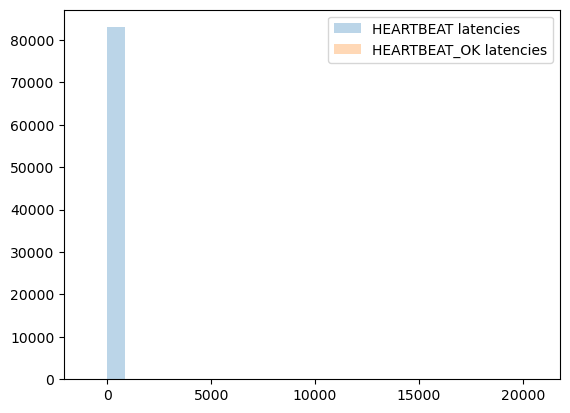

In [36]:
# get heartbeat residuals (effective network delays)
corrections = list()
HEARTBEAT_residuals = list()
HEARTBEAT_OK_residuals = list()
for (sub, exp, sess, orig_sess), heartbeats_sess in heartbeats.groupby(['subject', 'experiment', 'session', 'original_session']):
    print('------------------------------------------------------------------------------------------------')
    print(sub, exp, 'session', sess, 'original session', orig_sess)
    res = get_heartbeat_correction(heartbeats_sess, ignore_errors=True, verbose=True, plot=False)
    res['subject'] = sub
    res['experiment'] = exp
    res['session'] = sess
    res['original_session'] = orig_sess
    corrections.append(pd.DataFrame(res, index=np.arange(len(res))))
    
    # check on latencies to/from elemem across event types
    heartbeats_task = correct_event_times(heartbeats_sess.query('hardware_system == "task_laptop"'),
                                          res['offset'], res['slope'], time_col='time')
    heartbeats_task = correct_event_times(heartbeats_task,
                                          res['offset'], res['slope'], time_col='time_HEARTBEAT_OK').set_index('count')
    heartbeats_host = heartbeats_sess.query('hardware_system == "host_pc"').set_index('count')

    HEARTBEAT_residuals_sess = list(heartbeats_host.time - heartbeats_task.time)
    HEARTBEAT_OK_residuals_sess = list(heartbeats_host.time_HEARTBEAT_OK - heartbeats_task.time_HEARTBEAT_OK)
    HEARTBEAT_residuals.extend(HEARTBEAT_residuals_sess)
    HEARTBEAT_OK_residuals.extend(HEARTBEAT_OK_residuals_sess)
    
# plot all network delays
plt.hist(HEARTBEAT_residuals, bins=25, label='HEARTBEAT latencies', alpha=0.3)
plt.hist(HEARTBEAT_OK_residuals, bins=25, label='HEARTBEAT_OK latencies', alpha=0.3)
plt.legend()

corrections = pd.concat(corrections)

In [37]:
len(heartbeats)

166241

In [24]:
len(heartbeats.query('hardware_system == "task_laptop"'))

83214

In [20]:
len(HEARTBEAT_residuals_sess)

2059

In [21]:
len(HEARTBEAT_residuals)

83218

Proportion of HERTBEAT_OK delays > 25 ms: 0.01084%


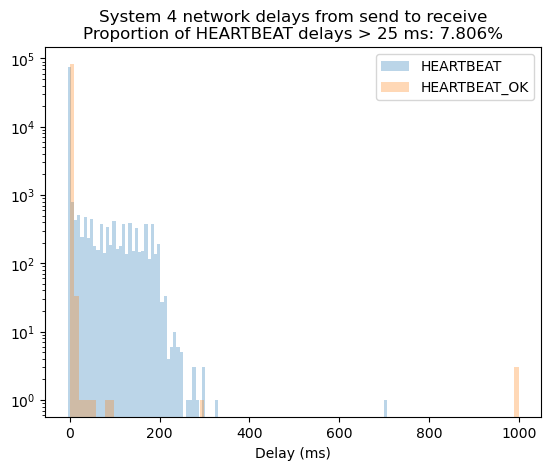

In [48]:
# plot network delays after excluding outliers

# exclude outliers
# mask = np.ones_like(HEARTBEAT_residuals).astype(bool)
mask = np.logical_and(np.abs(HEARTBEAT_residuals) < 1e3, np.abs(HEARTBEAT_OK_residuals) < 1e3)
plt.hist(np.array(HEARTBEAT_residuals)[mask], bins=100, label='HEARTBEAT', alpha=0.3)
plt.hist(-np.array(HEARTBEAT_OK_residuals)[mask], bins=100, label='HEARTBEAT_OK', alpha=0.3)
plt.yscale('log')
plt.legend()
plt.xlabel('Delay (ms)')
long_delay = 50  # ms
prop_long_delay = (np.abs(np.array(HEARTBEAT_residuals)[mask]) > long_delay).mean()
prop_long_delay_host = (np.abs(np.array(HEARTBEAT_OK_residuals)[mask]) > long_delay).mean()
_ = plt.title(f'System 4 network delays from send to receive\nProportion of HEARTBEAT delays > {long_delay} ms: {prop_long_delay * 100:0.4}%')
print(f'Proportion of HERTBEAT_OK delays > {long_delay} ms: {prop_long_delay_host * 100:0.4}%')


Event timing questions:

How are the following event columns derived in event_creation?
- eegoffset:
    - system 4: 
    - system 3: 
    - system 2: 
- mstime:
    - system 4: 
    - system 3: 
    - system 2: 

Can the existing event parsers be used for parsing the session.json/l (with minor adjustments)?

In [127]:
# check absolute HEARTBEAT event times
i = 15
mstime = heartbeats.time.iloc[i + 1]  # Example milliseconds timestamp
converted_datetime = ms_to_datetime(mstime)
print(f'Time of heartbeat {i + 1}:', converted_datetime)

converted_datetime1 = ms_to_datetime(heartbeats.time.iloc[i + 1])
converted_datetime2 = ms_to_datetime(heartbeats.time.iloc[i + 2])
print('Time to next heartbeat (s):', converted_datetime2 - converted_datetime1)


Time of heartbeat 16: 2024-01-28 11:23:44.277990
Time to next heartbeat (s): 0:00:01.001460


In [43]:
# confirm that HEARTBEATs are all separated by ~1 second
def check_heartbeat_onsets(heartbeats, min_heartbeat_diff=990, max_heartbeat_diff=1010):
    if len(heartbeats) == 0: return
    sess_cols = ['subject', 'experiment', 'session']
    heartbeats.loc[:, ['time_diff']] = heartbeats[sess_cols + ['time']].groupby(sess_cols).diff().reset_index(drop=True).to_numpy()
    heart_off = np.logical_or(heartbeats.time_diff.dropna() > max_heartbeat_diff, 
                              heartbeats.time_diff.dropna() < min_heartbeat_diff)
    if heart_off.mean():
        print(f'WARNING: some HEARTBEAT events not separated by approximately 1 second '
              f'(acceptable range: [{min_heartbeat_diff}, {max_heartbeat_diff}] ms). '
              f'Proportion of heartbeats outside range: {heart_off.mean()}')

check_heartbeat_onsets(heartbeats.query('hardware_system == "task_laptop"'))

Text(0.5, 0, 'Latency (ms)')

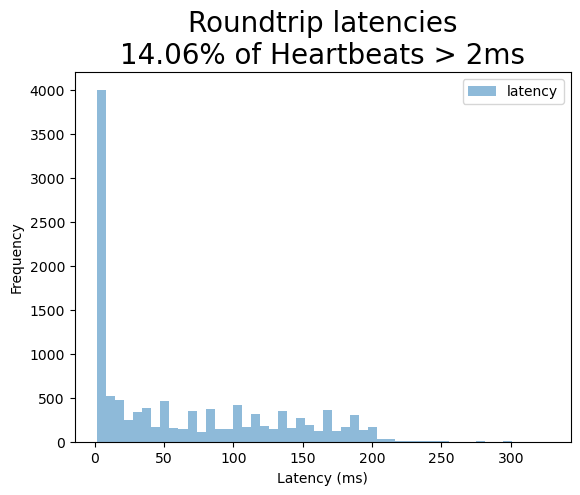

In [44]:
# plot heartbeat roundtrip latencies
bpm_err = heartbeats.query('hardware_system == "task_laptop"').copy().latency
# threshold for marking heartbeat trips as "high latency"
threshold = 2  # ms
norm = bpm_err[bpm_err < threshold].count()
bpm_err = bpm_err[bpm_err > threshold]
bpm_err = bpm_err[bpm_err < 1000]  # exclude extreme outliers (some latencies > 1e6)
no_norm = bpm_err[bpm_err > threshold].count()
percent = no_norm/(norm+no_norm) * 100
percent = round(percent, 2)

_max = int(round(bpm_err.max()))

# *** Sets up the axes for all of the plots
# set_axes(figsize = (7, 5), fontsize = 18)
bins = 50 #np.arange(0, _max+2, step = 1)
# *** Plots the latencies *** #
bpm_err.plot.hist(bins = bins, alpha = 0.5)
plt.legend()
plt.title(f'Roundtrip latencies\n{str(percent)}% of Heartbeats > {threshold}ms', fontsize=20)
plt.xlabel('Latency (ms)')
